In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv("11-iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.drop("Id",axis=1,inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


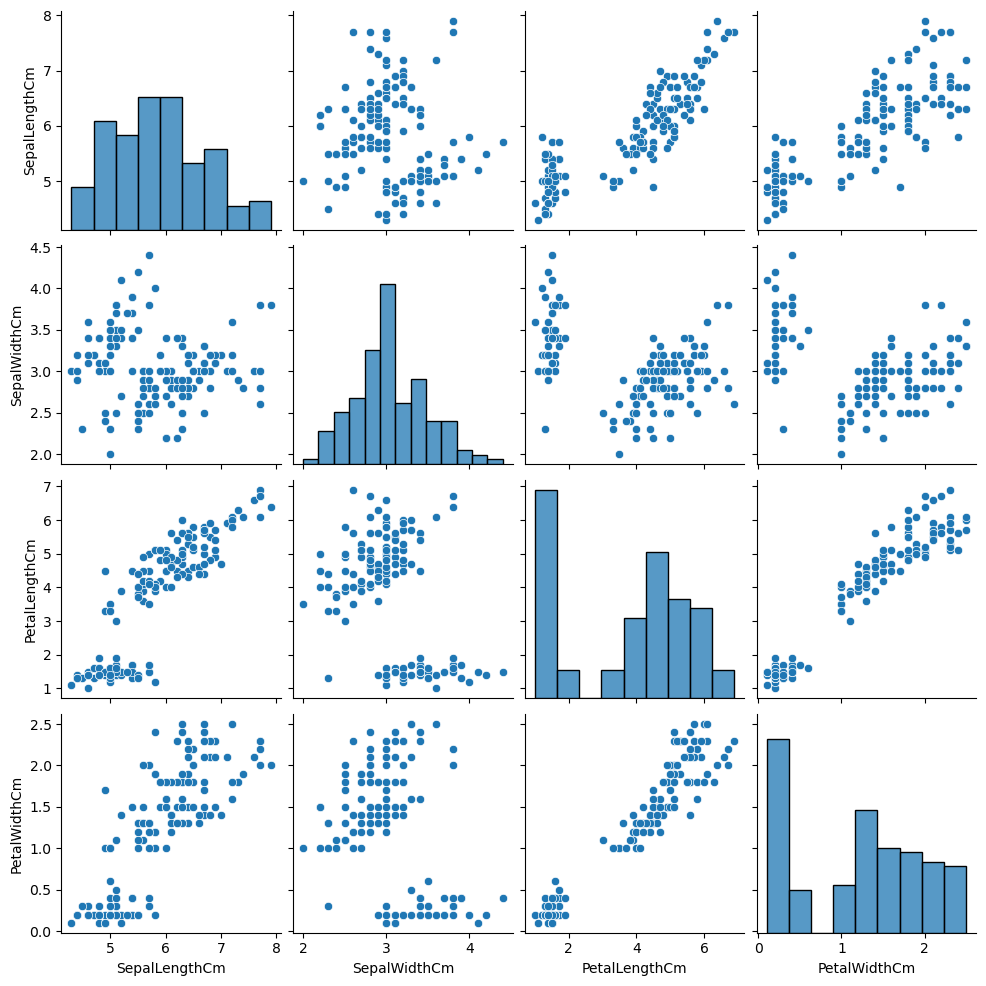

In [8]:
sns.pairplot(df)
plt.show()

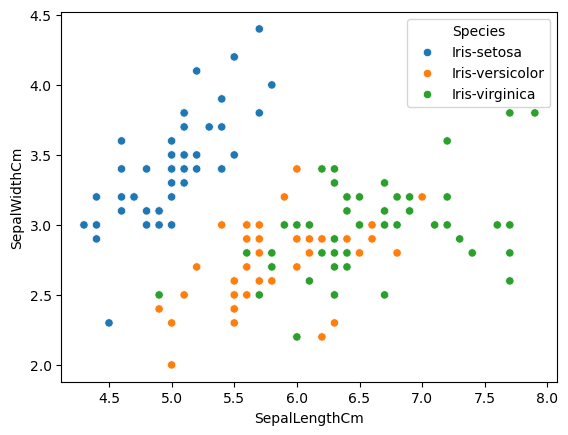

In [9]:
sns.scatterplot(x=df["SepalLengthCm"],y=df["SepalWidthCm"],hue=df["Species"])
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
label_encoder=LabelEncoder()
df["Species"]= label_encoder.fit_transform(df["Species"])

In [12]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X=df.drop("Species",axis=1)
y=df["Species"]

In [15]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.naive_bayes import GaussianNB

In [18]:
gnb = GaussianNB()

In [19]:
gnb.fit(X_train_scaled,y_train)
y_pred = gnb.predict(X_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [21]:
print("Accuracy Score \n" ,accuracy_score(y_pred,y_test))
print("COnfusion Matrix \n" ,confusion_matrix(y_pred,y_test))
print("Classification Report \n" ,classification_report(y_pred,y_test))

Accuracy Score 
 1.0
COnfusion Matrix 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [22]:
from sklearn.svm import SVC
svc = SVC(kernel="rbf")
svc.fit(X_train_scaled,y_train)

SVC()

In [23]:
y_pred=svc.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score

In [25]:
print("R2 Score \n" ,r2_score(y_pred,y_test))
print("MAE \n" ,mean_absolute_error(y_pred,y_test))
print("MSE \n" ,mean_squared_error(y_pred,y_test))

R2 Score 
 1.0
MAE 
 0.0
MSE 
 0.0


In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C":[0.1,00.1,1,100],
    "gamma":[0.01, 0.1, 1],
    "kernel":["rbf","linear"]
}
grid = GridSearchCV(estimator=SVC(),param_grid=param_grid,refit=True,n_jobs=-1)
grid.fit(X_train_scaled,y_train)

GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 0.1, 1, 100], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear']})

In [27]:
y_pred=grid.predict(X_test_scaled)

In [28]:
print("R2 Score \n" ,r2_score(y_pred,y_test))
print("MAE \n" ,mean_absolute_error(y_pred,y_test))
print("MSE \n" ,mean_squared_error(y_pred,y_test))

R2 Score 
 1.0
MAE 
 0.0
MSE 
 0.0


In [29]:
print("Accuracy Score \n" ,accuracy_score(y_pred,y_test))
print("COnfusion Matrix \n" ,confusion_matrix(y_pred,y_test))
print("Classification Report \n" ,classification_report(y_pred,y_test))

Accuracy Score 
 1.0
COnfusion Matrix 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [30]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression()

In [31]:
penalty=["l1","l2","elasticnet" ]
c_values=[1,10,5,100]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [32]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [33]:
grid = GridSearchCV(estimator=LogisticRegression(),param_grid=params,refit=True,n_jobs=-1)

In [34]:
import warnings 
warnings.filterwarnings('ignore') 
grid.fit(X_train,y_train)

GridSearchCV(estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [1, 10, 5, 100],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']})

In [35]:
y_pred=grid.predict(X_test)

In [36]:
grid.best_params_

{'C': 1, 'class_weight': {0: 1, 1: 1}, 'penalty': 'l1', 'solver': 'saga'}

In [37]:
print("Accuracy Score \n" ,accuracy_score(y_pred,y_test))
print("COnfusion Matrix \n" ,confusion_matrix(y_pred,y_test))
print("Classification Report \n" ,classification_report(y_pred,y_test))

Accuracy Score 
 0.9736842105263158
COnfusion Matrix 
 [[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [38]:
print("R2 Score \n" ,r2_score(y_pred,y_test))
print("MAE \n" ,mean_absolute_error(y_pred,y_test))
print("MSE \n" ,mean_squared_error(y_pred,y_test))

R2 Score 
 0.9599578503688093
MAE 
 0.02631578947368421
MSE 
 0.02631578947368421
